## Imports

In [8]:
import re
from collections import Counter

import sys
import os

sys.path.append(os.path.abspath("../numpy"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import Data
from layers import DenseLayer
from activation import ReLUActivation, SoftmaxActivation
from neuralnet import NeuralNetwork
from losses import CategoricalCrossEntropy
from metrics import accuracy

## Ler os datasets

In [9]:
train_df = pd.read_csv("../dataset_final.csv", sep=";")
test_df = pd.read_csv("../subm1.csv", sep=";")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (6996, 3)
Test shape: (150, 2)


,ID,Text,Label
0,D1-0001,Photocatalytic water splitting uses semiconduc...,Anthropic
1,D1-0002,Placental pathology provides critical informat...,Anthropic
2,D1-0003,Surgical pathology involves the examination of...,Meta
3,D1-0004,The configuration space network (CSN) of a dyn...,Human
4,D1-0005,The pathology of aging focuses on the biologic...,Meta


,ID,Text
0,D2-1,A covalent bond is a chemical bond that involv...
1,D2-2,A covalent bond forms when two atoms share one...
2,D2-3,A covalent bond is a type of chemical bond whe...
3,D2-4,A covalent bond is a chemical bond that involv...
4,D2-5,Driven by exciting developments in the field o...


## Limpeza de texto

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text



cleanText=False ####################################### mudar 

if cleanText:
    train_df["clean_text"] = train_df["Text"].apply(clean_text)
    test_df["clean_text"] = test_df["Text"].apply(clean_text)
    print("com texto limpo")
else:
    train_df["clean_text"] = train_df["Text"]
    test_df["clean_text"] = test_df["Text"]
    print("sem texto limpo")

display(train_df[["Text", "clean_text", "Label"]].head())

sem texto limpo


,Text,clean_text,Label
0,Photocatalytic water splitting uses semiconduc...,Photocatalytic water splitting uses semiconduc...,Anthropic
1,Placental pathology provides critical informat...,Placental pathology provides critical informat...,Anthropic
2,Surgical pathology involves the examination of...,Surgical pathology involves the examination of...,Meta
3,The configuration space network (CSN) of a dyn...,The configuration space network (CSN) of a dyn...,Human
4,The pathology of aging focuses on the biologic...,The pathology of aging focuses on the biologic...,Meta


## Ver classes

In [11]:
print("Classes:")
print(train_df["Label"].value_counts())

Classes:
Label
OpenAI       1583
Google       1582
Meta         1544
Anthropic    1397
Human         890
Name: count, dtype: int64


## Construir vocabulário

Bag of Words

In [12]:
def build_vocab(texts, max_features=5000, min_freq=2):
    counter = Counter()
    
    for text in texts:
        counter.update(text.split())
    
    vocab_items = [
        word for word, freq in counter.items()
        if freq >= min_freq
    ]
    
    vocab_items = sorted(
        vocab_items,
        key=lambda word: counter[word],
        reverse=True
    )[:max_features]
    
    vocab = {word: idx for idx, word in enumerate(vocab_items)}
    return vocab



## Transformar texto em Bag of Words

In [13]:
def text_to_bow(texts, vocab):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float32)
    
    for i, text in enumerate(texts):
        for word in text.split():
            if word in vocab:
                X[i, vocab[word]] += 1.0
                
    return X


## Transformar texto em TFIDF

In [14]:
def compute_idf(texts, vocab):
    n_docs = len(texts)
    df = np.zeros(len(vocab), dtype=np.float32)

    for text in texts:
        seen_words = set()
        for word in text.split():
            if word in vocab and word not in seen_words:
                df[vocab[word]] += 1
                seen_words.add(word)

    idf = np.log((n_docs + 1) / (df + 1)) + 1
    return idf

def text_to_tfidf(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float32)

    for i, text in enumerate(texts):
        words = text.split()
        if len(words) == 0:
            continue

        for word in words:
            if word in vocab:
                X[i, vocab[word]] += 1.0

        X[i] = X[i] / len(words)
        X[i] = X[i] * idf

        # normalização L2 (melhora bastante)
        norm = np.linalg.norm(X[i])
        if norm > 0:
            X[i] = X[i] / norm


    return X


## Codificar labels

In [15]:
def fit_label_encoder(labels):
    classes = sorted(labels.unique())
    label_to_idx = {label: i for i, label in enumerate(classes)}
    idx_to_label = {i: label for label, i in label_to_idx.items()}
    return label_to_idx, idx_to_label

def encode_labels(labels, label_to_idx):
    return np.array([label_to_idx[label] for label in labels], dtype=np.int32)

def one_hot_encode(y, num_classes):
    y_onehot = np.zeros((len(y), num_classes), dtype=np.float32)
    y_onehot[np.arange(len(y)), y] = 1.0
    return y_onehot


## Split treino / validação

In [16]:
def train_val_split(X, y, val_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    split_idx = int(len(X) * (1 - val_size))
    train_idx = indices[:split_idx]
    val_idx = indices[split_idx:]
    
    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]

texts = train_df["clean_text"].to_numpy()
labels = train_df["Label"].to_numpy()

X_train_text, X_val_text, y_train_text, y_val_text = train_val_split(texts, labels, val_size=0.2, seed=42)

print("X_train:", X_train_text.shape)
print("X_val:", X_val_text.shape)
print("y_train:", y_train_text.shape)
print("y_val:", y_val_text.shape)

X_train: (5596,)
X_val: (1400,)
y_train: (5596,)
y_val: (1400,)


In [17]:
## vedadeiro = tfidf    falso = bow 
def build_features(X_train_text,X_val_text,use_tfidf=True):
    if use_tfidf:
        idf = compute_idf(X_train_text, vocab)

        X_train = text_to_tfidf(X_train_text, vocab, idf)
        X_val = text_to_tfidf(X_val_text, vocab, idf)
        
    else:
        X_train = text_to_bow(X_train_text, vocab)
        X_val = text_to_bow(X_val_text, vocab)
        

    return X_train, X_val

In [18]:
vocab = build_vocab(X_train_text)

print("Vocabulary size:", len(vocab))
print("Primeiras 20 palavras:", list(vocab.keys())[:20])

Vocabulary size: 5000
Primeiras 20 palavras: ['the', 'and', 'of', 'to', 'a', 'in', 'is', 'for', 'that', 'are', 'as', 'The', 'by', 'or', 'with', 'on', 'from', 'which', 'This', 'can']


In [19]:
label_to_idx, idx_to_label = fit_label_encoder(train_df["Label"])

y_train_idx = encode_labels(y_train_text, label_to_idx)
y_val_idx = encode_labels(y_val_text, label_to_idx)

num_classes = len(label_to_idx)
y_train = one_hot_encode(y_train_idx, num_classes)
y_val = one_hot_encode(y_val_idx, num_classes)

print("Classes:", label_to_idx)
print("y_val shape:", y_val.shape)

Classes: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}
y_val shape: (1400, 5)


In [20]:
X_train, X_val= build_features(X_train_text, X_val_text,use_tfidf=False)  #false to use Bow 

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)


X_train: (5596, 5000)
X_val: (1400, 5000)


## Criar objetos Data

In [21]:
train_data = Data(X_train, y_train)
val_data = Data(X_val, y_val)


## Baseline — Logistic Regression multi-classe


In [22]:
logreg = NeuralNetwork(
    epochs=70,
    batch_size=32,
    learning_rate=0.05,
    momentum=0.9,
    verbose=True,
    loss=CategoricalCrossEntropy,
    metric=accuracy
)
val_pred_logreg = logreg.predict(val_data)
val_acc_logreg = accuracy(y_val, val_pred_logreg)

print("Validation accuracy - Logistic Regression:", val_acc_logreg)

logreg.add(DenseLayer(num_classes, input_shape=(X_train.shape[1],)))
logreg.add(SoftmaxActivation())

logreg.fit(train_data, val_dataset=val_data, early_stopping=True, patience=5)

Validation accuracy - Logistic Regression: 0.12428571428571429
Epoch 1/70 - loss: 2.5382 - acc: 0.3604 - val_loss: 1.8965 - val_acc: 0.4714
Epoch 2/70 - loss: 1.6685 - acc: 0.5029 - val_loss: 1.5457 - val_acc: 0.5393
Epoch 3/70 - loss: 1.3304 - acc: 0.5693 - val_loss: 1.3355 - val_acc: 0.5914
Epoch 4/70 - loss: 1.1111 - acc: 0.6356 - val_loss: 1.1993 - val_acc: 0.6200
Epoch 5/70 - loss: 0.9526 - acc: 0.6771 - val_loss: 1.1117 - val_acc: 0.6521
Epoch 6/70 - loss: 0.8382 - acc: 0.7085 - val_loss: 1.0151 - val_acc: 0.6714
Epoch 7/70 - loss: 0.7457 - acc: 0.7393 - val_loss: 0.9823 - val_acc: 0.6750
Epoch 8/70 - loss: 0.6753 - acc: 0.7652 - val_loss: 0.9341 - val_acc: 0.6950
Epoch 9/70 - loss: 0.6089 - acc: 0.7843 - val_loss: 0.8953 - val_acc: 0.7121
Epoch 10/70 - loss: 0.5563 - acc: 0.8004 - val_loss: 0.8491 - val_acc: 0.7171
Epoch 11/70 - loss: 0.5118 - acc: 0.8193 - val_loss: 0.8234 - val_acc: 0.7343
Epoch 12/70 - loss: 0.4724 - acc: 0.8313 - val_loss: 0.7937 - val_acc: 0.7436
Epoch 13/7

## Avaliar baseline no conjunto de validação

In [23]:
val_pred_logreg = logreg.predict(val_data)
val_acc_logreg = accuracy(y_val, val_pred_logreg)

print("Validation accuracy - Logistic Regression:", val_acc_logreg)

Validation accuracy - Logistic Regression: 0.8157142857142857


## Ver evolução do treino do baseline

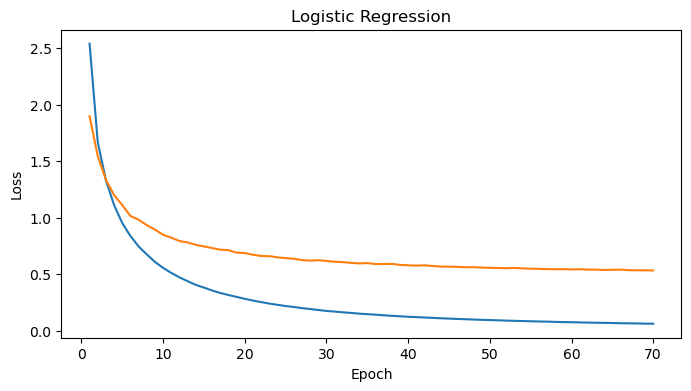

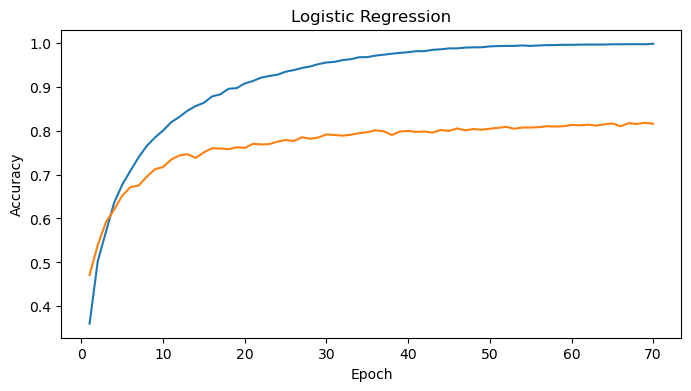

In [24]:
epochs_logreg = list(logreg.history.keys())
losses_logreg = [logreg.history[e]["loss"] for e in epochs_logreg]
metrics_logreg = [logreg.history[e]["metric"] for e in epochs_logreg]
val_losses_logreg = [logreg.history[e]["val_loss"] for e in epochs_logreg]
val_metrics_logreg = [logreg.history[e]["val_metric"] for e in epochs_logreg]

plt.figure(figsize=(8, 4))
plt.plot(epochs_logreg, losses_logreg, label= "Train Loss")
plt.plot(epochs_logreg, val_losses_logreg, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Logistic Regression")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_logreg, metrics_logreg, label="Train Accuracy")
plt.plot(epochs_logreg, val_metrics_logreg, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Logistic Regression")
plt.show()

## DNN multi-classe

In [25]:
X_train, X_val= build_features(X_train_text, X_val_text,use_tfidf=True)  #false to use Bow 

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

train_data = Data(X_train, y_train)
val_data = Data(X_val, y_val)

dnn = NeuralNetwork(
    epochs=50,
    batch_size=32,
    learning_rate=0.1,
    momentum=0.9,
    verbose=True,
    loss=CategoricalCrossEntropy,
    metric=accuracy
)

dnn.add(DenseLayer(128, input_shape=(X_train.shape[1],)))
dnn.add(ReLUActivation())
dnn.add(DenseLayer(64))
dnn.add(ReLUActivation())
dnn.add(DenseLayer(num_classes))
dnn.add(SoftmaxActivation())

dnn.fit(train_data, val_dataset=val_data, early_stopping=True, patience=5)

X_train: (5596, 5000)
X_val: (1400, 5000)
Epoch 1/50 - loss: 1.5774 - acc: 0.2884 - val_loss: 1.4586 - val_acc: 0.3571
Epoch 2/50 - loss: 1.3326 - acc: 0.4274 - val_loss: 1.3056 - val_acc: 0.4250
Epoch 3/50 - loss: 1.1786 - acc: 0.5082 - val_loss: 1.2065 - val_acc: 0.4750
Epoch 4/50 - loss: 1.0544 - acc: 0.5683 - val_loss: 1.1222 - val_acc: 0.5129
Epoch 5/50 - loss: 0.9452 - acc: 0.6160 - val_loss: 1.0548 - val_acc: 0.5586
Epoch 6/50 - loss: 0.8479 - acc: 0.6612 - val_loss: 0.9897 - val_acc: 0.5807
Epoch 7/50 - loss: 0.7576 - acc: 0.7084 - val_loss: 0.9763 - val_acc: 0.6021
Epoch 8/50 - loss: 0.6764 - acc: 0.7384 - val_loss: 0.9228 - val_acc: 0.6164
Epoch 9/50 - loss: 0.5991 - acc: 0.7727 - val_loss: 0.8911 - val_acc: 0.6321
Epoch 10/50 - loss: 0.5403 - acc: 0.7966 - val_loss: 0.8676 - val_acc: 0.6479
Epoch 11/50 - loss: 0.4738 - acc: 0.8252 - val_loss: 0.8585 - val_acc: 0.6586
Epoch 12/50 - loss: 0.4174 - acc: 0.8494 - val_loss: 0.8393 - val_acc: 0.6829
Epoch 13/50 - loss: 0.3636 - ac

## Avaliar DNN

In [26]:
val_pred_dnn = dnn.predict(val_data)
val_acc_dnn = accuracy(y_val, val_pred_dnn)

print("Validation accuracy - DNN:", val_acc_dnn)

Validation accuracy - DNN: 0.6985714285714286


## Ver evolução do treino da DNN

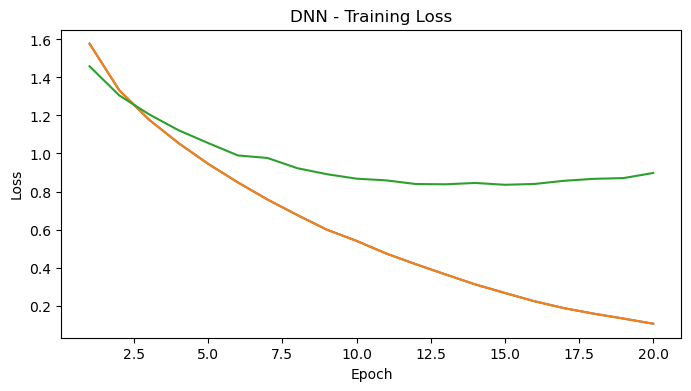

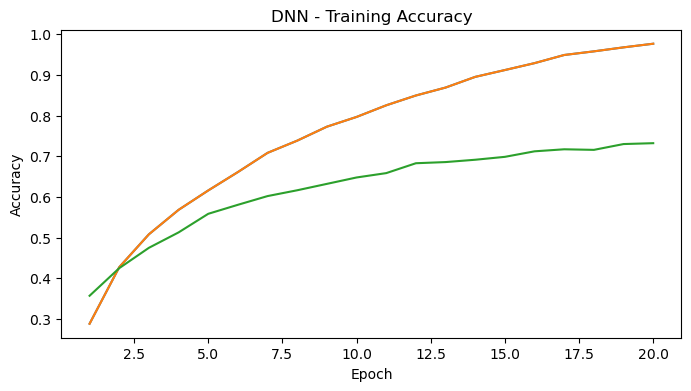

In [27]:
epochs_dnn = list(dnn.history.keys())
losses_dnn = [dnn.history[e]["loss"] for e in epochs_dnn]
metrics_dnn = [dnn.history[e]["metric"] for e in epochs_dnn]
val_losses_dnn = [dnn.history[e]["val_loss"] for e in epochs_dnn]
val_metrics_dnn = [dnn.history[e]["val_metric"] for e in epochs_dnn]

plt.figure(figsize=(8, 4))
plt.plot(epochs_dnn, losses_dnn)
plt.plot(epochs_dnn, losses_dnn, label= "Train Loss")
plt.plot(epochs_dnn, val_losses_dnn, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DNN - Training Loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_dnn, metrics_dnn)
plt.plot(epochs_dnn, metrics_dnn, label="Train Accuracy")
plt.plot(epochs_dnn, val_metrics_dnn, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DNN - Training Accuracy")
plt.show()

## Escolher o melhor modelo

In [28]:
idf = compute_idf(X_train_text, vocab)

if val_acc_dnn >= val_acc_logreg:
    best_model = dnn
    best_model_name = "DNN"
    X_test_final = text_to_tfidf(test_df["clean_text"].to_numpy(), vocab, idf)

else:
    best_model = logreg
    best_model_name = "Logistic Regression"
    X_test_final = text_to_bow(test_df["clean_text"].to_numpy(), vocab)

    

print("Best model:", best_model_name)

Best model: Logistic Regression


## Prever o subm1.csv

In [29]:
test_data = Data(X_test_final, y=None)

test_pred = best_model.predict(test_data)
test_pred_idx = np.argmax(test_pred, axis=1)
test_pred_labels = [idx_to_label[i] for i in test_pred_idx]

print(test_pred_labels[:10])

['Google', 'Google', 'Meta', 'Meta', 'Human', 'Anthropic', 'Anthropic', 'Meta', 'Google', 'Human']


## Criar ficheiro de submissão

In [30]:
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "Text": test_df["Text"],
    "Label": test_pred_labels
})

display(submission.head())

submission.to_csv("subm1-g6-MEI-A.csv", sep=";", index=False)
print("submission.csv guardado com sucesso.")

,ID,Text,Label
0,D2-1,A covalent bond is a chemical bond that involv...,Google
1,D2-2,A covalent bond forms when two atoms share one...,Google
2,D2-3,A covalent bond is a type of chemical bond whe...,Meta
3,D2-4,A covalent bond is a chemical bond that involv...,Meta
4,D2-5,Driven by exciting developments in the field o...,Human


submission.csv guardado com sucesso.


## matriz de confusão simples

In [31]:
def confusion_matrix_numpy(y_true, y_pred, num_classes):
    if y_true.ndim > 1:
        y_true = np.argmax(y_true, axis=1)
    if y_pred.ndim > 1:
        y_pred = np.argmax(y_pred, axis=1)
    
    cm = np.zeros((num_classes, num_classes), dtype=int)
    
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
        
    return cm

cm_dnn = confusion_matrix_numpy(y_val, val_pred_dnn, num_classes)
cm_df = pd.DataFrame(
    cm_dnn,
    index=[idx_to_label[i] for i in range(num_classes)],
    columns=[idx_to_label[i] for i in range(num_classes)]
)

display(cm_df)

,Anthropic,Google,Human,Meta,OpenAI
Anthropic,176,23,6,29,46
Google,20,252,4,47,5
Human,10,6,131,5,0
Meta,18,85,1,208,18
OpenAI,60,12,1,26,211
